## Predicting heart disease using machine learning

This motebook looks into using various Python-based ML and DS libraries
in an attemt to build a ML model capable of predicting whether or not 
someone has heart disease based on their medical attributes.

We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentattion

## 1.Problem Definition

In a statement,
> Given clinical parameters about a patient, can we predict whether or not they heart disease?

## 2. Data

## 3.Evaluation

> If we can reach 95% accuracy at predicting whther or not a patient has heart disease during the proof of concept, we'll persue the project.

## 4. Features

This is where you'all get diff infor about each of the features in your data. You can do this via doing your own research(such as looking at the links above) or by talking to a subject matter expert(someone who knows about the dataset).

# Create data dictionary

1. age: Patient age in years
2. sex: Gender (1 = male; 0 = female)
3. cp: Chest pain type (4 values)
4. trestbps: Resting blood pressure (in mm Hg on admission)
5. chol: Serum cholesterol in mg/dl
6. fbs: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
7. restecg: Resting electrocardiographic results (values 0, 1, 2)
8. thalach: Maximum heart rate achieved
9. exang: Exercise-induced angina (1 = yes; 0 = no)

10. oldpeak: ST depression induced by exercise relative to rest
11. slope: The slope of the peak exercise ST segment
12. ca: Number of major vessels (0-3) colored by fluoroscopy
13. thal: Thalassemia (0 = normal; 1 = fixed defect; 2 = reversible defect)
14. target / num: Diagnosis of heart disease (predicted value from 0 to 4, or binary 0 for absence and 1-4 for presence) [1] 

## Preparing the tools
We're going to use pandas, Matplotlib and Numpy for data analysis and manipulation.

In [1]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
#from sklearn.metrics import plot_roc_curve

## LOAD DATA

In [2]:
df= pd.read_csv("heart_disease (1).csv")
df.shape # rows, columns

(109, 9)

## Data Exploration (exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter export
on the dataset you're working with.

 1. What questions are you trying to solve?
 2. What kind of data do we have and how do we trat diggerent type ?
 3. What missing from the data and how do you deal with it?
 4. Where are the outiers and why should you care about them ?
 5. How can you add, change or remove features to get more out of your data?

In [3]:
df.head()

,Age,Sex,ChestPain,RestingBP,Cholesterol,MaxHeartRate,ExerciseAngina,Oldpeak,HeartDisease
0,63,1,ATA,145,233,150,N,2.3,1
1,37,1,NAP,130,250,187,N,3.5,0
2,41,0,ATA,130,204,172,N,1.4,0
3,56,1,ASY,140,294,153,Y,1.3,1
4,57,0,NAP,120,354,163,N,0.6,0


In [4]:
df.tail()

,Age,Sex,ChestPain,RestingBP,Cholesterol,MaxHeartRate,ExerciseAngina,Oldpeak,HeartDisease
104,52,1,ATA,125,220,160,N,0.0,0
105,67,1,ASY,160,286,108,Y,1.5,1
106,40,0,ATA,120,180,170,N,0.0,0
107,55,1,NAP,130,240,150,N,0.8,0
108,62,1,ASY,145,280,125,Y,2.5,1


In [9]:
df["target"] = df["HeartDisease"]


In [11]:
df.head()

,Age,Sex,ChestPain,RestingBP,Cholesterol,MaxHeartRate,ExerciseAngina,Oldpeak,HeartDisease,target
0,63,1,ATA,145,233,150,N,2.3,1,1
1,37,1,NAP,130,250,187,N,3.5,0,0
2,41,0,ATA,130,204,172,N,1.4,0,0
3,56,1,ASY,140,294,153,Y,1.3,1,1
4,57,0,NAP,120,354,163,N,0.6,0,0


In [8]:
# Lets find out how many of each class there
df["target"].value_counts()

target
0    63
1    46
Name: count, dtype: int64

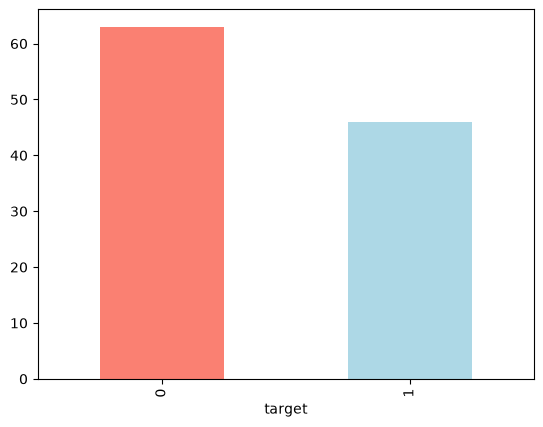

In [13]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             109 non-null    int64  
 1   Sex             109 non-null    int64  
 2   ChestPain       109 non-null    str    
 3   RestingBP       109 non-null    int64  
 4   Cholesterol     109 non-null    int64  
 5   MaxHeartRate    109 non-null    int64  
 6   ExerciseAngina  109 non-null    str    
 7   Oldpeak         109 non-null    float64
 8   HeartDisease    109 non-null    int64  
 9   target          109 non-null    int64  
dtypes: float64(1), int64(7), str(2)
memory usage: 8.6 KB


In [15]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,MaxHeartRate,Oldpeak,HeartDisease,target
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,52.807339,0.724771,131.715596,243.651376,147.155963,1.117431,0.422018,0.422018
std,8.227638,0.448693,13.047699,47.359808,22.141454,1.215398,0.496163,0.496163
min,35.000000,0.000000,105.000000,160.000000,87.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,120.000000,207.000000,130.000000,0.000000,0.000000,0.000000
50%,53.000000,1.000000,130.000000,239.000000,150.000000,1.000000,0.000000,0.000000
75%,59.000000,1.000000,140.000000,275.000000,163.000000,1.800000,1.000000,1.000000
max,69.000000,1.000000,172.000000,417.000000,187.000000,6.200000,1.000000,1.000000


## Heart Disease Frequency according to Sex

In [18]:
df.Sex.value_counts()

Sex
1    79
0    30
Name: count, dtype: int64

In [20]:
# Compare target column with sex column
pd.crosstab(df.target, df.Sex)

Sex,0,1
target,,
0,26,37
1,4,42


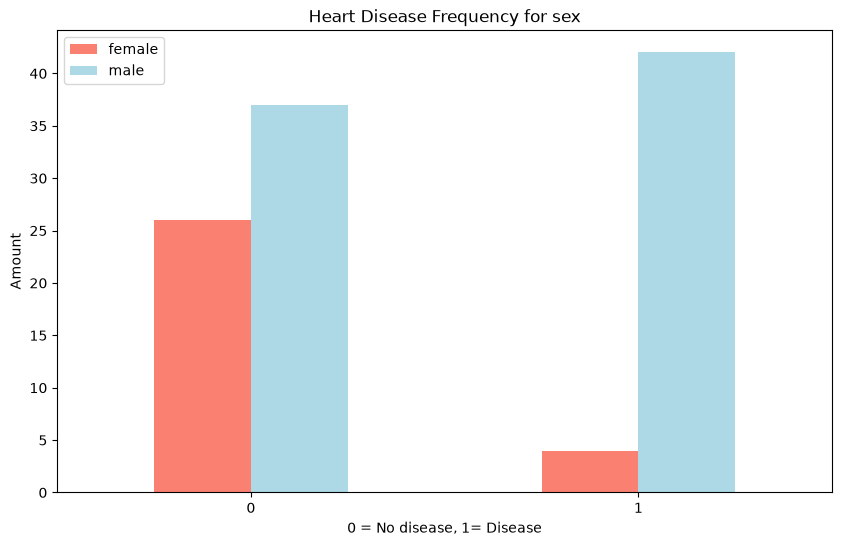

In [24]:
# Create a plot of crosstab
pd.crosstab(df.target, df.Sex).plot(kind="bar",
                                    figsize=(10, 6),
                                    color=["salmon", "lightblue"]);

plt.title("Heart Disease Frequency for sex")
plt.xlabel("0 = No disease, 1= Disease")
plt.ylabel("Amount")
plt.legend(["female","male"]);
plt.xticks(rotation=0);

## Age vs. Max Heart Rate for Heart Disease

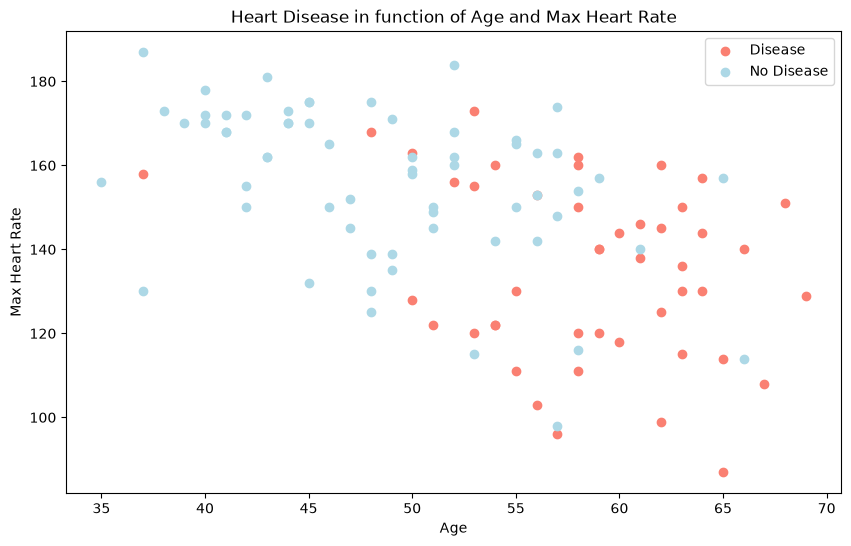

In [40]:
# create another figure
plt.figure(figsize=(10,6))

# Scatter with positive examples
plt.scatter(df.Age[df.target ==1],
            df.thalach[df.target ==1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df.Age[df.target ==0],
            df.thalach[df.target ==0],
            c="lightblue")
# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);


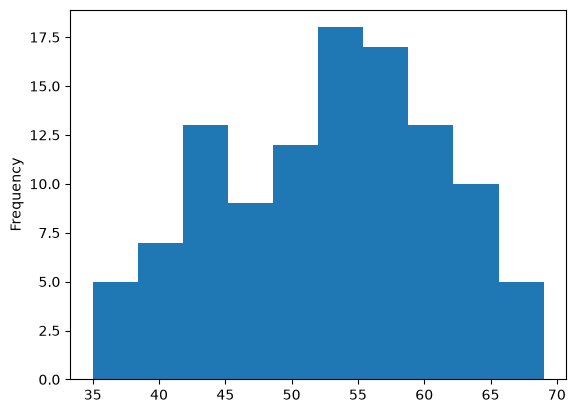

In [44]:
# CHEACK THE DISTRIBUTION OF THE AGE COLUMNS WITH A HISTOGRAM
df.Age.plot.hist();

## Heart Disease Frequency per Chest Pain Type
3.cp-chest pain type

    * TA. Typical angina: chest pain related decrease blood supply to the heart
    * ATA. Atypical angina: chest pain not related to heart
    * NAP. Non-angina pain: typically esophageal spasms (non heart related)
    * ASY. Asymptomatic: chest pain not showing signs of disease


In [42]:
pd.crosstab(df.ChestPain, df.target)

target,0,1
ChestPain,,
ASY,2,38
ATA,39,2
NAP,21,6
TA,1,0


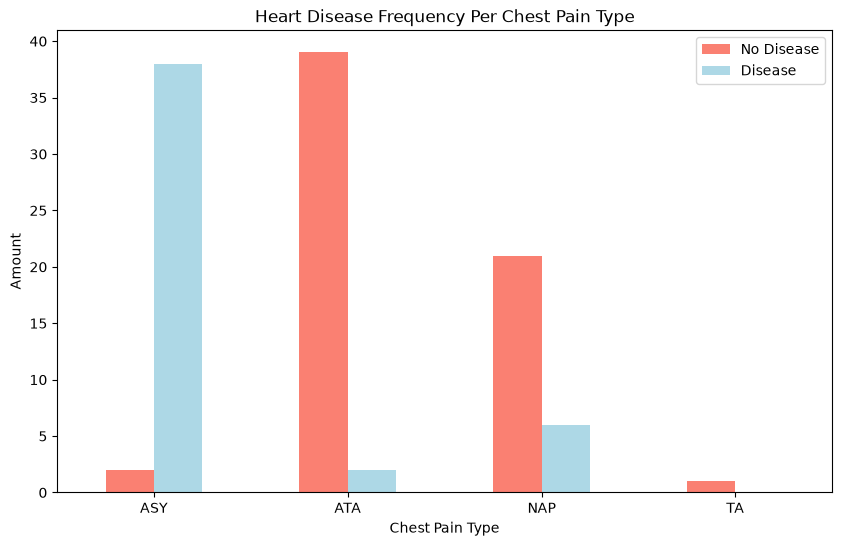

In [47]:
# make the crosstab more visual
pd.crosstab(df.ChestPain, df.target).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["salmon","lightblue"])

# add some communication
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

In [48]:
df.head()

,Age,Sex,ChestPain,RestingBP,Cholesterol,ExerciseAngina,Oldpeak,HeartDisease,target,thalach
0,63,1,ATA,145,233,N,2.3,1,1,150
1,37,1,NAP,130,250,N,3.5,0,0,187
2,41,0,ATA,130,204,N,1.4,0,0,172
3,56,1,ASY,140,294,Y,1.3,1,1,153
4,57,0,NAP,120,354,N,0.6,0,0,163


In [51]:
# make a correletion matrix
# df.corr()
df.corr(numeric_only = True)

,Age,Sex,RestingBP,Cholesterol,Oldpeak,HeartDisease,target,thalach
Age,1.000000,0.080813,0.454980,0.225308,0.406548,0.589414,0.589414,-0.532196
Sex,0.080813,1.000000,0.147828,-0.151398,0.216021,0.360204,0.360204,-0.098160
RestingBP,0.454980,0.147828,1.000000,0.111755,0.484294,0.417757,0.417757,-0.264327
Cholesterol,0.225308,-0.151398,0.111755,1.000000,0.089384,0.161572,0.161572,-0.094225
Oldpeak,0.406548,0.216021,0.484294,0.089384,1.000000,0.534306,0.534306,-0.290328
HeartDisease,0.589414,0.360204,0.417757,0.161572,0.534306,1.000000,1.000000,-0.472138
target,0.589414,0.360204,0.417757,0.161572,0.534306,1.000000,1.000000,-0.472138
thalach,-0.532196,-0.098160,-0.264327,-0.094225,-0.290328,-0.472138,-0.472138,1.000000


(8.5, -0.5)

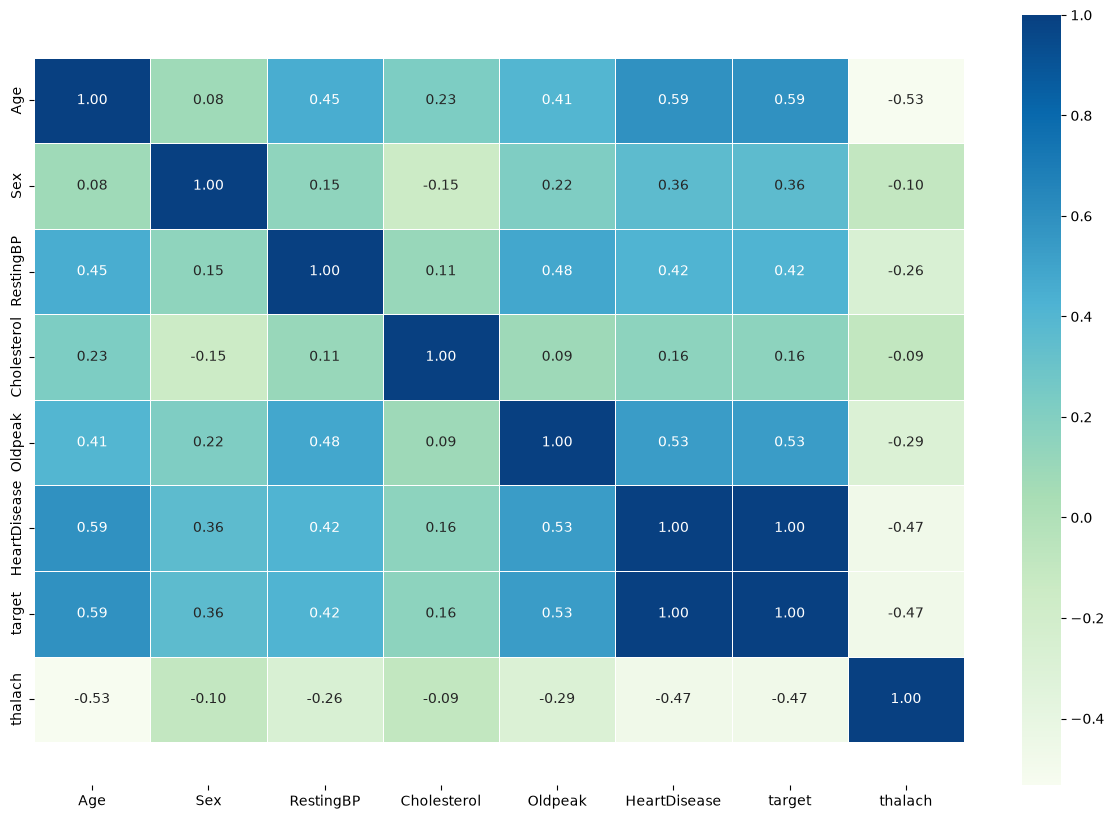

In [69]:
# Lets make our correletion matrix a little prettier
corr_matrix = df.corr(numeric_only= True)
fig, ax= plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix,
                 annot= True,
                 linewidths= 0.5,
                 fmt=".2f",
                 cmap="GnBu");

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

## 5. Modelling

In [70]:
df.head()

,Age,Sex,ChestPain,RestingBP,Cholesterol,ExerciseAngina,Oldpeak,HeartDisease,target,thalach
0,63,1,ATA,145,233,N,2.3,1,1,150
1,37,1,NAP,130,250,N,3.5,0,0,187
2,41,0,ATA,130,204,N,1.4,0,0,172
3,56,1,ASY,140,294,Y,1.3,1,1,153
4,57,0,NAP,120,354,N,0.6,0,0,163


In [71]:
# split data into X and y
X= df.drop("target", axis=1)

y= df["target"]

In [72]:
X

,Age,Sex,ChestPain,RestingBP,Cholesterol,ExerciseAngina,Oldpeak,HeartDisease,thalach
0,63,1,ATA,145,233,N,2.3,1,150
1,37,1,NAP,130,250,N,3.5,0,187
2,41,0,ATA,130,204,N,1.4,0,172
3,56,1,ASY,140,294,Y,1.3,1,153
4,57,0,NAP,120,354,N,0.6,0,163
...,...,...,...,...,...,...,...,...,...
104,52,1,ATA,125,220,N,0.0,0,160
105,67,1,ASY,160,286,Y,1.5,1,108
106,40,0,ATA,120,180,N,0.0,0,170
107,55,1,NAP,130,240,N,0.8,0,150


In [73]:
y

0      1
1      0
2      0
3      1
4      0
      ..
104    0
105    1
106    0
107    0
108    1
Name: target, Length: 109, dtype: int64

In [74]:
# Split data into train and test sets
np.random.seed(42)

# Split into train & test set
X_train, X_train, y_train, y_test = train_test_split(X,
                                                     y,
                                                     test_size=0.2)

In [75]:
X_train

,Age,Sex,ChestPain,RestingBP,Cholesterol,ExerciseAngina,Oldpeak,HeartDisease,thalach
78,49,0,NAP,130,207,N,0.0,0,135
10,54,1,ASY,140,239,N,1.2,1,160
4,57,0,NAP,120,354,N,0.6,0,163
84,48,0,ATA,120,229,N,0.0,0,175
64,57,1,ASY,130,207,Y,1.0,1,96
68,47,1,ATA,108,243,N,0.0,0,152
30,65,1,ASY,140,306,Y,1.5,1,87
45,43,0,ATA,130,315,N,1.9,0,162
96,46,0,ATA,110,202,N,0.0,0,150
11,48,0,ATA,130,275,N,0.2,0,139


In [76]:
y_train, len(y_train)

(65     0
 26     1
 22     0
 31     0
 47     0
       ..
 71     0
 14     1
 92     1
 51     0
 102    0
 Name: target, Length: 87, dtype: int64,
 87)

Now we've got our split into training and test sets, its time to build a ML model.

We'll train it(find the patterns) on the training set.

And we'll test it(use the patterns) on the test set.

We're going to try 3 different ML models:
1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier

In [95]:
# Put models in a dictionary
models= {"Logistic Regression": LogisticRegression(max_iter=1000),
         "KNN": KNeighborsClassifier(),
         "Random Forest": RandomForestClassifier()
        }

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given ML models.
    models: a dict of differentn Scikit-Laern ML models
    X_train : training data (no labels)
    X_test : testing data(no labels)
    y_train : training labels
    y_test : test labels
    """ # doc string
    # set random seed
    np.random.seed(42)
    # make a dictionary to keep model scores
    model_scores= {} # emty dict
    #loop through models
    for name, model in models.items():
        #fit the model to the data
        model.fit(X_train, y_train)
        # evaluate the model and append it score to model_scores
        model_scores[name]= model.score(X_test, y_test)
    return model_scores

In [96]:
model_scores = fit_and_score(models=models,
                            X_train= X_train,
                            X_test= X_test,
                            y_train= y_train,
                            y_test= y_test)
model_scores

{'Logistic Regression': 0.9545454545454546,
 'KNN': 0.7272727272727273,
 'Random Forest': 1.0}